#**Pipeline**

In [6]:
import pandas as pd
import numpy as np
import requests
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

##DuckDB

In [7]:
import duckdb
import pandas as pd

#connect to in-memory DuckDB database
con = duckdb.connect()

#load all parquet files directly into DuckDB tables
con.execute("CREATE TABLE weather_events  AS SELECT * FROM read_parquet('data/weather_events.parquet')")
con.execute("CREATE TABLE climate_monthly AS SELECT * FROM read_parquet('data/climate_monthly.parquet')")
con.execute("CREATE TABLE soil_moisture   AS SELECT * FROM read_parquet('data/soil_moisture_monthly.parquet')")
con.execute("CREATE TABLE drought_monitor AS SELECT * FROM read_parquet('data/drought_monitor.parquet')")
con.execute("CREATE TABLE master          AS SELECT * FROM read_parquet('data/master.parquet')")

#confirming all tables loaded
print('Tables loaded into DuckDB:')
print(con.execute("SHOW TABLES").df().to_string(index=False))

Tables loaded into DuckDB:
           name
climate_monthly
drought_monitor
         master
  soil_moisture
 weather_events


##Database Queries

In [8]:
#query 1: how many flood events occurred each year?
q1 = con.execute("""
    SELECT
        YEAR,
        COUNT(*)                    AS total_flood_events,
        COUNT(DISTINCT EVENT_TYPE)  AS event_types
    FROM weather_events
    GROUP BY YEAR
    ORDER BY YEAR
""").df()
print('Flood events by year:')
display(q1)

Flood events by year:


,YEAR,total_flood_events,event_types
0,2015,4,1
1,2016,7,2
2,2017,3,2
3,2018,41,2
4,2019,3,1
5,2020,31,1
6,2021,7,2
7,2022,8,2
8,2023,6,1
9,2024,27,2


In [9]:
#query 2: which months are highest flood risk?
q2 = con.execute("""
    SELECT
        MONTH,
        SUM(HAD_FLOOD)                          AS flood_months,
        COUNT(*)                                AS total_months,
        ROUND(AVG(HAD_FLOOD) * 100, 1)          AS flood_pct,
        ROUND(AVG(PRCP_TOTAL), 2)               AS avg_precip_in,
        ROUND(AVG(SOIL_MOISTURE_MEAN), 3)       AS avg_soil_moisture
    FROM master
    GROUP BY MONTH
    ORDER BY MONTH
""").df()
print('Flood risk by month:')
display(q2)

Flood risk by month:


,MONTH,flood_months,total_months,flood_pct,avg_precip_in,avg_soil_moisture
0,1,1.0,10,10.0,2.99,0.463
1,2,2.0,10,20.0,2.85,0.467
2,3,0.0,10,0.0,2.48,0.443
3,4,2.0,10,20.0,3.54,0.417
4,5,5.0,10,50.0,4.52,0.407
5,6,3.0,10,30.0,3.76,0.377
6,7,8.0,10,80.0,3.87,0.358
7,8,6.0,10,60.0,3.94,0.380
8,9,4.0,10,40.0,3.79,0.379
9,10,3.0,10,30.0,3.36,0.413


In [10]:
#query 3: compare conditions in flood vs non-flood months
q3 = con.execute("""
    SELECT
        HAD_FLOOD,
        COUNT(*)                                AS n_months,
        ROUND(AVG(PRCP_TOTAL), 2)               AS avg_precip,
        ROUND(AVG(PRCP_MAX), 2)                 AS avg_max_daily_rain,
        ROUND(AVG(HEAVY_RAIN_DAYS), 2)          AS avg_heavy_rain_days,
        ROUND(AVG(SOIL_MOISTURE_MEAN), 3)       AS avg_soil_moisture,
        ROUND(AVG(DROUGHT_INDEX), 3)            AS avg_drought_index
    FROM master
    GROUP BY HAD_FLOOD
    ORDER BY HAD_FLOOD
""").df()
q3['HAD_FLOOD'] = q3['HAD_FLOOD'].map({0: 'No flood', 1: 'Flood'})
print('Average conditions — flood months vs non-flood months:')
display(q3)

Average conditions — flood months vs non-flood months:


,HAD_FLOOD,n_months,avg_precip,avg_max_daily_rain,avg_heavy_rain_days,avg_soil_moisture,avg_drought_index
0,No flood,82,2.62,0.96,0.55,0.417,0.525
1,Flood,38,5.18,1.81,1.58,0.407,0.300


##Model Implementation

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#loading master table and defining features
master = pd.read_parquet('data/master.parquet')

FEATURES = [
    'PRCP_TOTAL_LAG1',
    'PRCP_MAX_LAG1',
    'HEAVY_RAIN_DAYS',
    'TMAX_MEAN',
    'SOIL_MOISTURE_MEAN_LAG1',
    'SOIL_MOISTURE_MAX_LAG1',
    'DROUGHT_INDEX_LAG1',
    'MONTH'
]
TARGET = 'HAD_FLOOD'

#drop the first row (NaN from lag) and any other nulls
model_df = master[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES]
y = model_df[TARGET]

print(f'Samples: {len(model_df)}')

Samples: 119


In [13]:
#train model with cross-validation
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,             #shallow to avoid overfitting on small dataset
    class_weight='balanced', #corrects for more flood months than non-flood
    random_state=88
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=88)

#cross_val_predict gives one prediction per sample across all folds
y_pred = cross_val_predict(rf, X, y, cv=cv)

print(classification_report(y, y_pred, target_names=['No flood', 'Flood']))

#fit on full dataset so we can extract feature importances
rf.fit(X, y)

              precision    recall  f1-score   support

    No flood       0.81      0.85      0.83        81
       Flood       0.65      0.58      0.61        38

    accuracy                           0.76       119
   macro avg       0.73      0.72      0.72       119
weighted avg       0.76      0.76      0.76       119



RandomForestClassifier(class_weight='balanced', max_depth=4, random_state=88)

In [14]:
#predicted flood probability by condition
#uses the fitted random forest to show how flood probability changes across low / medium / high values of the three strongest predictors

rf.fit(X, y)
baseline = model_df.median()[FEATURES]  #start from median conditions

#potential scenarios for flood probability
scenarios = {
    'Baseline (median conditions)':          {},
    'Low prior precipitation (<1 in)':       {'PRCP_TOTAL_LAG1': 0.8},
    'High prior precipitation (>4 in)':      {'PRCP_TOTAL_LAG1': 4.5},
    'Low soil moisture (<0.22)':             {'SOIL_MOISTURE_MEAN_LAG1': 0.20},
    'High soil moisture (>0.35)':            {'SOIL_MOISTURE_MEAN_LAG1': 0.37},
    'No drought (index = 0)':               {'DROUGHT_INDEX_LAG1': 0.0},
    'Moderate drought (index > 1)':          {'DROUGHT_INDEX_LAG1': 1.5},
    'High precip + high soil moisture':      {'PRCP_TOTAL_LAG1': 4.5,
                                              'SOIL_MOISTURE_MEAN_LAG1': 0.37},
}

#takes median value and updates probability based on flood occurrance
rows = []
for label, overrides in scenarios.items():
    scenario = baseline.copy()
    for col, val in overrides.items():
        scenario[col] = val
    prob = rf.predict_proba(scenario.values.reshape(1, -1))[0][1]
    rows.append({'Scenario': label, 'Flood probability': f'{prob*100:.1f}%'})

scenario_df = pd.DataFrame(rows)
print(f'Overall flood rate in data: {y.mean()*100:.1f}%\n')
display(scenario_df)

Overall flood rate in data: 31.9%



,Scenario,Flood probability
0,Baseline (median conditions),57.0%
1,Low prior precipitation (<1 in),42.4%
2,High prior precipitation (>4 in),62.8%
3,Low soil moisture (<0.22),53.5%
4,High soil moisture (>0.35),54.3%
5,No drought (index = 0),57.0%
6,Moderate drought (index > 1),55.0%
7,High precip + high soil moisture,58.9%


##Analysis Rationale

A random forest classifier was selected for this analysis because it handles the small dataset size (120 monthly observations), mixed feature types, and class imbalance between flood and non-flood months well. Shallow trees with a maximum depth of four were used to prevent overfitting on a dataset of this size, and the class_weight='balanced' parameter was set to correct for the fact that flood months outnumber non-flood months roughly two to one in Albemarle County over the study period. Features were constructed as lag-1 values of the prior month's precipitation, soil moisture, and drought conditions rather than same-month values in order to preserve the causal direction of the model. The goal is to predict whether a flood will occur based on antecedent environmental conditions, not to describe conditions during a flood that has already happened. Five-fold stratified cross-validation was used to evaluate model performance, which ensures that the flood-to-non-flood ratio is preserved across all folds and that every month in the dataset is used for both training and testing exactly once, giving an honest estimate of how the model would perform on unseen data. The primary evaluation metric is the classification report rather than raw accuracy, since accuracy alone is misleading when one class is more common than the other (for example, a model that always predicts "flood" would achieve over 60% accuracy in this dataset without learning anything useful).

##Visualizations

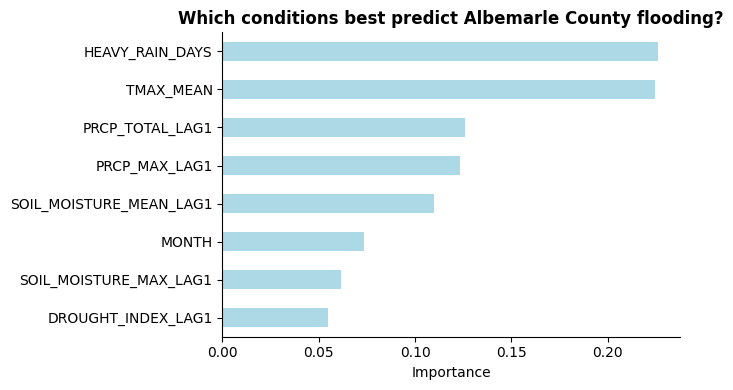

In [15]:
#visualization 1: feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='lightblue')
ax.set_xlabel('Importance')
ax.set_title('Which conditions best predict Albemarle County flooding?',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

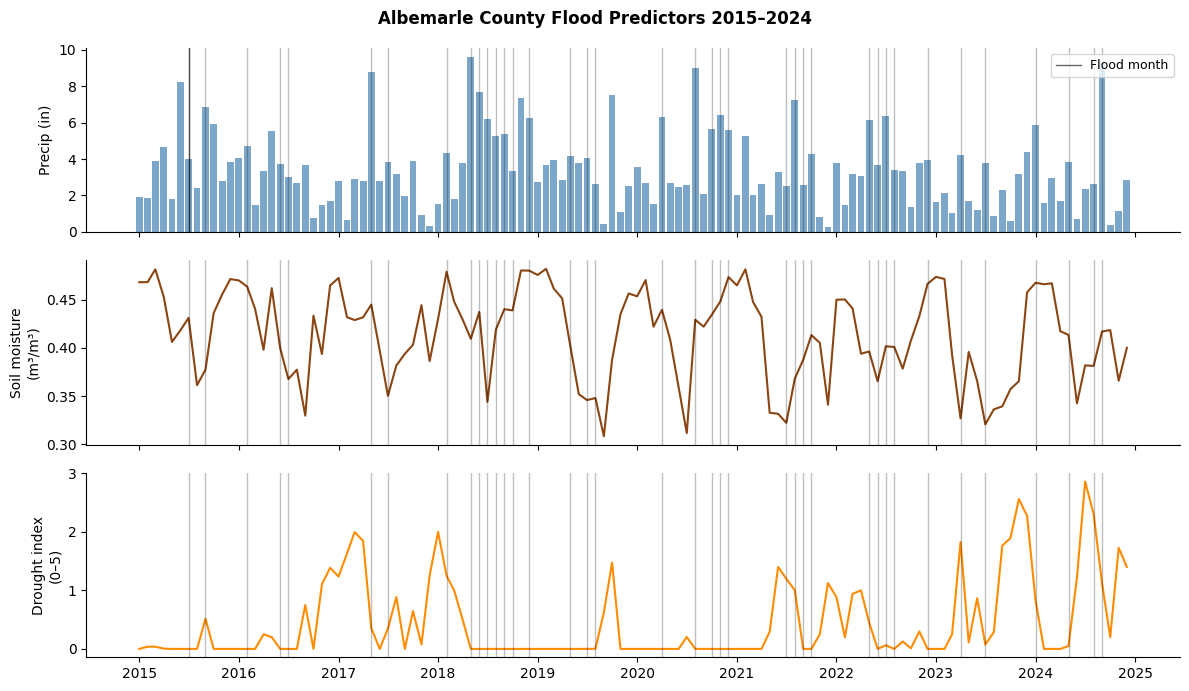

In [16]:
#visualization 2: flood events and key predictors over time
plot_df = master.dropna(subset=['SOIL_MOISTURE_MEAN', 'PRCP_TOTAL']).copy()
plot_df['DATE'] = pd.to_datetime(plot_df[['YEAR','MONTH']].assign(DAY=1))
flood_dates = plot_df[plot_df['HAD_FLOOD'] == 1]['DATE']

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Albemarle County Flood Predictors 2015–2024',
             fontweight='bold', fontsize=12)

#precipitation
axes[0].bar(plot_df['DATE'], plot_df['PRCP_TOTAL'],
            color='steelblue', alpha=0.7, width=25)
axes[0].set_ylabel('Precip (in)')

#soil moisture
axes[1].plot(plot_df['DATE'], plot_df['SOIL_MOISTURE_MEAN'],
             color='saddlebrown', linewidth=1.5)
axes[1].set_ylabel('Soil moisture\n(m³/m³)')

#drought index
axes[2].plot(plot_df['DATE'], plot_df['DROUGHT_INDEX'],
             color='darkorange', linewidth=1.5)
axes[2].set_ylabel('Drought index\n(0–5)')

#mark flood months on all panels
for ax in axes:
    for d in flood_dates:
        ax.axvline(d, color='black', alpha=0.25, linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#single shared legend
axes[0].axvline(flood_dates.iloc[0], color='black', alpha=0.6,
                linewidth=1, label='Flood month')
axes[0].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('data/flood_predictors_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

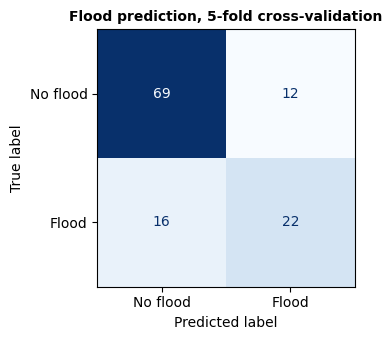

In [17]:
#visualization 3: confusion matrix
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['No flood', 'Flood'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Flood prediction, 5-fold cross-validation',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

##Visualization Rationale

**Visualization 1:**

The feature importance chart was chosen because it directly helps answer the question of the project, which is which environmental conditions actually drive flood risk in Albemarle County. The visualization puts this information in a form that is interpretable to a non-technical audience. A horizontal bar chart was used rather than a table because the visual ranking makes it immediately clear which predictors dominate without requiring the reader to scan numbers. The chart is fitted on the full dataset rather than a single cross-validation fold so the importances reflect the model's overall learned behavior rather than one split of the data.


**Visualization 2:**


The three-panel time series was chosen to show the raw temporal patterns in the data before any modeling, which frames the results in observable reality rather than just model outputs. Sharing the x-axis across all three panels lets the reader visually see how precipitation, soil moisture, and drought conditions have moved together over time and compare those movements against the gray flood month markers. This graph is particularly useful for communicating the lag relationship because you can see that flood months often follow periods of elevated soil moisture and precipitation rather than coinciding with drought spikes. This helps validate the modeling decision to use lag-1 features.

**Visualization 3:**

The confusion matrix was chosen because ROC-AUC and accuracy scores alone are abstract and hard to communicate to a non-technical audience. It makes the two types of mistakes the model can make easy to see, which are predicting a flood that doesn't happen (false positive) and missing a flood that does (false negative). It allows a reader to judge which failure mode is more acceptable for their use case. Cross-validation predictions were used rather than training-set predictions to ensure the matrix reflects out-of-sample performance rather than overfitted results on data the model has already seen.